# [Tarea 07] Unidad 03-B | splines cúbicos
### Damian Aguilar


## Diríjase al pseudocódigo del spline cúbico con frontera natural provisto en clase, en base a ese pseudocódigo complete la siguiente función: 

In [5]:
import sympy as sym
from IPython.display import display


# ###################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between  contiguous xs

    alpha = [0] * (n + 1) ## Es dado para completar por los numero de puntos, basicamente el tamaño
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]] # z es el resultado de la sustitucion hacia adelante

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a = ys[j]
        print(j, a, b, c[j], d)
        S  = a + b * (x - xs[j]) + c[j] * (x - xs[j]) ** 2 + d * (x - xs[j]) ** 3

        splines.append(S)
    splines.reverse()
    return splines

4) Usando la función anterior, encuentre el spline cúbico para: 
xs = [1, 2, 3] 
ys = [2, 3, 5] 

In [6]:
import sympy as sym
from IPython.display import display

# 1. Definir los puntos de entrada basados en tu consulta
xs = [1, 2, 3] 
ys = [2, 3, 5]

# 2. Llamar a la función cubic_spline definida en las fuentes
# Esta función devuelve una lista de expresiones simbólicas de SymPy [1]
polinomios_spline = cubic_spline(xs, ys)

# 3. Mostrar los resultados
print("Los polinomios resultantes para cada intervalo son:")
for i, s in enumerate(polinomios_spline):
    print(f"Intervalo {i} (entre x={xs[i]} y x={xs[i+1]}):")
    display(s)

1 3 1.5 0.75 -0.25
0 2 0.75 0.0 0.25
Los polinomios resultantes para cada intervalo son:
Intervalo 0 (entre x=1 y x=2):


0.75*x + 0.25*(x - 1)**3 + 1.25

Intervalo 1 (entre x=2 y x=3):


1.5*x - 0.25*(x - 2)**3 + 0.75*(x - 2)**2

5) Usando la función anterior, encuentre el spline cúbico para: 
xs = [0, 1, 2, 3] 
ys = [-1 ,1, 5, 2] 

In [7]:

# 1. Definir los puntos de entrada basados en tu consulta
xs =  [0, 1, 2, 3]  
ys =  [-1 ,1, 5, 2]

# 2. Llamar a la función cubic_spline definida en las fuentes
# Esta función devuelve una lista de expresiones simbólicas de SymPy [1]
polinomios_spline2 = cubic_spline(xs, ys)

# 3. Mostrar los resultados
print("Los polinomios resultantes para cada intervalo son:")
for i, s in enumerate(polinomios_spline2):
    print(f"Intervalo {i} (entre x={xs[i]} y x={xs[i+1]}):")
    display(s)

2 5 1.0 -6.0 2.0
1 1 4.0 3.0 -3.0
0 -1 1.0 0.0 1.0
Los polinomios resultantes para cada intervalo son:
Intervalo 0 (entre x=0 y x=1):


1.0*x**3 + 1.0*x - 1

Intervalo 1 (entre x=1 y x=2):


4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0

Intervalo 2 (entre x=2 y x=3):


1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0

## El link del repositorio no parece estar activo.
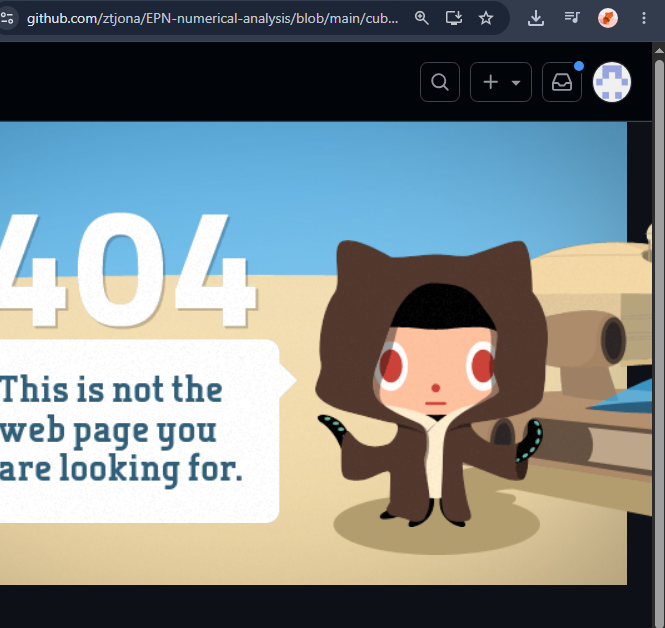 